In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
df=pd.read_csv("/content/drive/MyDrive/ML Models/train (1).csv")

In [5]:
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.shape

(891, 12)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handle Null Values

In [12]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [13]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
df.drop("Cabin",axis=1,inplace=True)

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Remove Unnecessary Columns

In [17]:
df.drop(['PassengerId',"Name","Ticket"],axis=1,inplace=True)

In [18]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [19]:
df.duplicated().sum()

np.int64(116)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

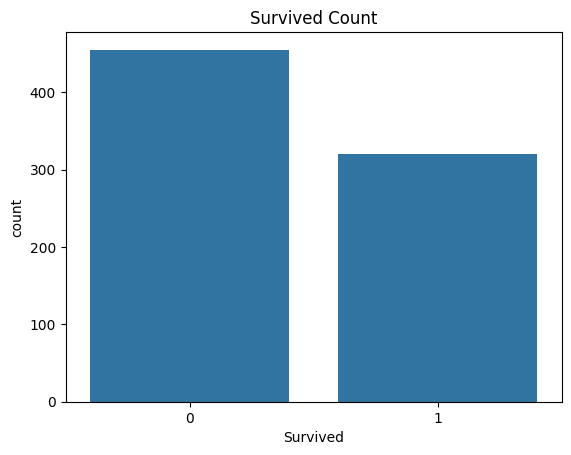

In [22]:
## Chek the survived Count

sns.countplot(x=df['Survived'])
plt.title("Survived Count")
plt.show()

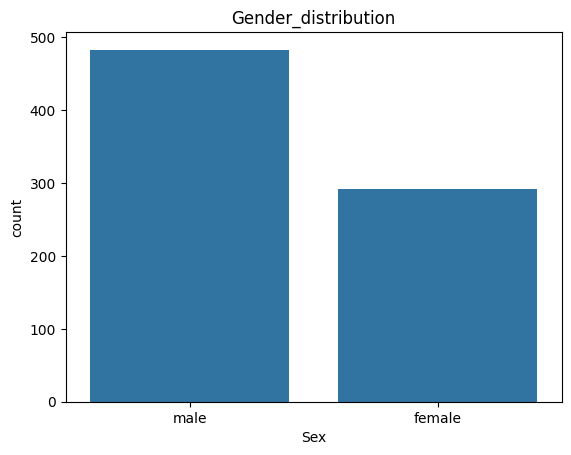

In [23]:
## Chek the Gender wise

sns.countplot(x=df['Sex'])
plt.title("Gender_distribution")
plt.show()

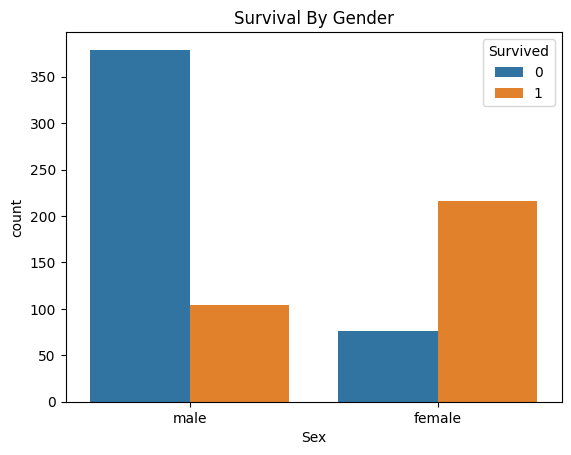

In [24]:
## check Survival By Gender
sns.countplot(x=df['Sex'],hue=df['Survived'])
plt.title("Survival By Gender")
plt.show()

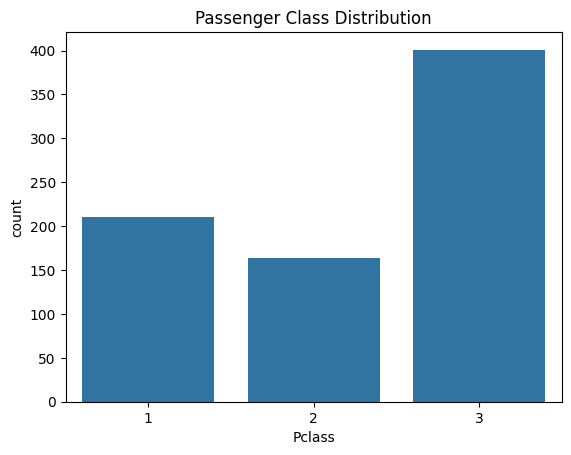

In [25]:
## Passanger clss Distribution

sns.countplot(x=df["Pclass"])

plt.title("Passenger Class Distribution")

plt.show()

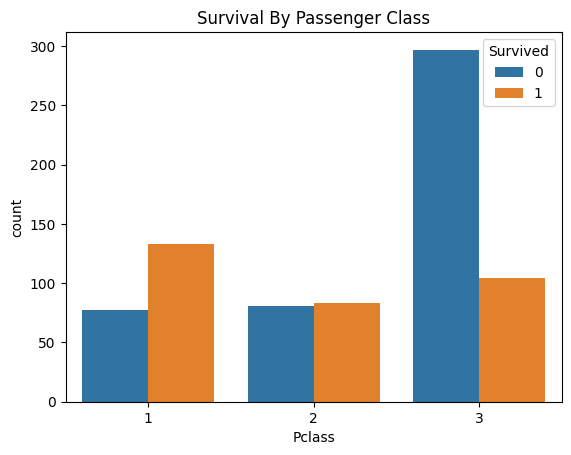

In [26]:
## Survival By Passenger Class

sns.countplot(x=df["Pclass"],hue=df["Survived"])
plt.title("Survival By Passenger Class")
plt.show()

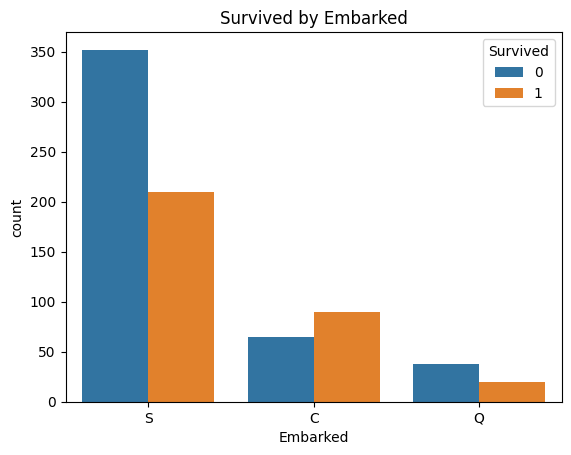

In [49]:
sns.countplot(x=df['Embarked'],hue=df['Survived'])
plt.title("Survived by Embarked")
plt.show()

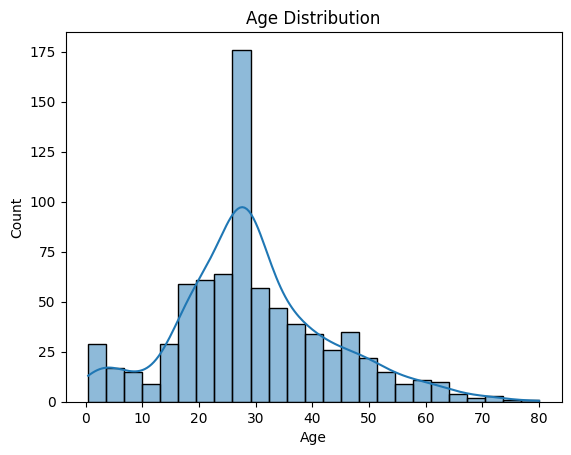

In [27]:
##  Age Distribution

sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution")
plt.show()

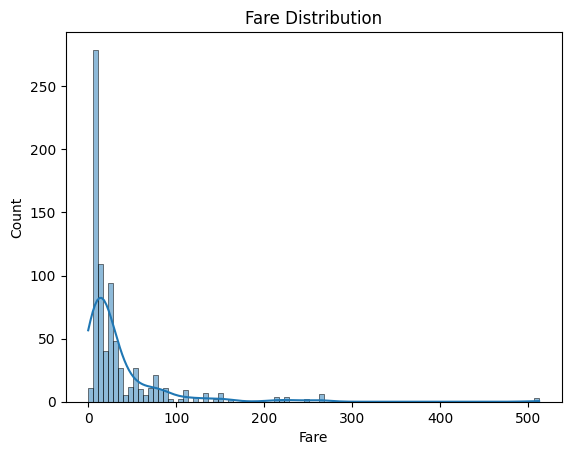

In [28]:
## Fare Distribution

sns.histplot(df["Fare"], kde=True)

plt.title("Fare Distribution")

plt.show()

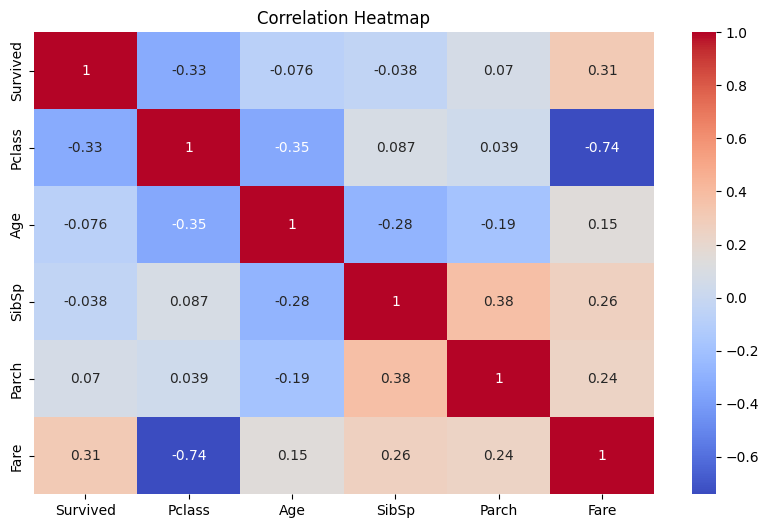

In [44]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

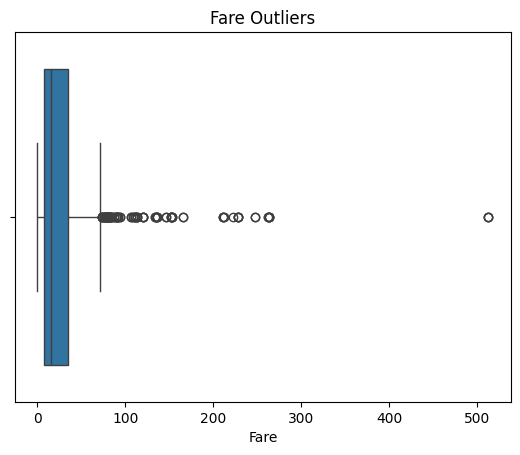

In [29]:
## Outlier With box plot

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.show()

# **Remove outlier from Fare by Capping**

In [30]:
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)

IQR=Q3-Q1

IQR

np.float64(26.147900000000003)

In [31]:
upper_limit=Q3+1.5*IQR
lower_limit=0

In [32]:
df['Fare']=np.where(df['Fare']>upper_limit,upper_limit,np.where(df['Fare']<lower_limit,lower_limit,df['Fare']))

In [33]:
print((df['Fare']>upper_limit).sum())

0


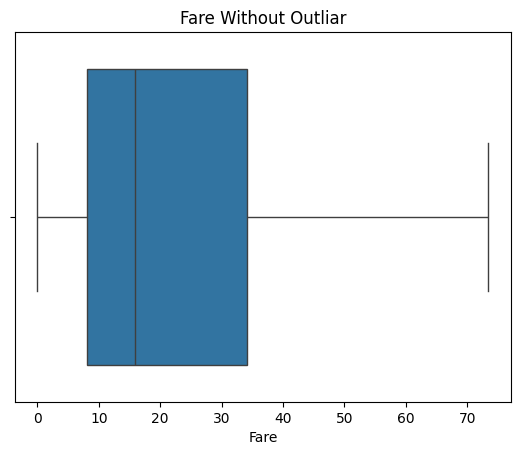

In [34]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Without Outliar")
plt.show()

## Remove outliar from Age Columnn with Capping

<Axes: xlabel='Age'>

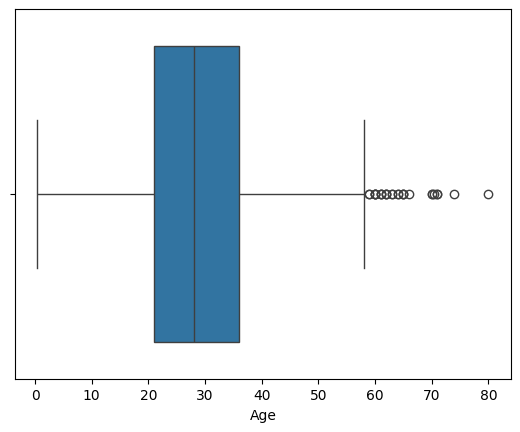

In [35]:
## Remove outliar from Age Columnn with Capping

sns.boxplot(x=df['Age'])


In [36]:
# Age column me 80 se jyada values dekhna

df["Age"].unique()

array([22.  , 38.  , 26.  , 35.  , 28.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  ,  8.  ,
       19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  ,
       29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 ,
       20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  , 60.  ,
       10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,
       24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [37]:
Q1=df['Age'].quantile(0.25)
Q3=df["Age"].quantile(0.75)

IQR=Q3-Q1

IQR

np.float64(15.0)

In [38]:
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR

In [39]:
lower_limit

np.float64(-1.5)

In [40]:
print((df['Age']<lower_limit).sum())

0


In [41]:
upper_limit

np.float64(58.5)

In [42]:
df['Age']=np.where(df['Age']>upper_limit,upper_limit,np.where(df['Age']<lower_limit,lower_limit,df['Age']))

<Axes: xlabel='Age'>

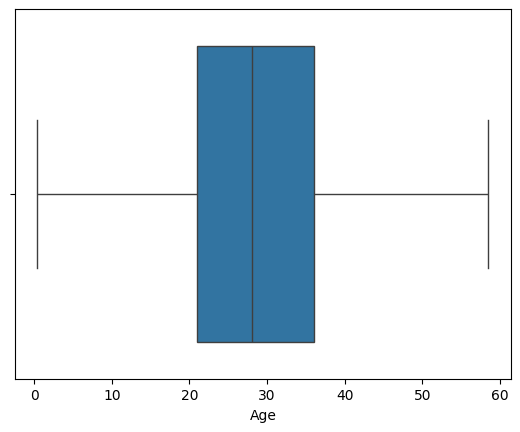

In [43]:
sns.boxplot(x=df['Age'])

# Check Dataset Shape After Outlier Removal

In [45]:
df.shape

(775, 8)

In [46]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [47]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [48]:
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [51]:
df['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

# Label Encoding

Machine learning models cannot understand text data. Therefore, they convert categorical data into numbers.

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
le=LabelEncoder()

df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])

In [55]:
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [60]:
df["Embarked"].unique()

array([2, 0, 1])

## Feature & Target Split

In [62]:
x = df.drop("Survived",axis=1)
y = df['Survived']

Explanation
X

Input data/features

y

Target/output

In [63]:
###  Train test ssplit

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Explanation

test_size=0.2
80% training
20% testing

# Feature Scaling

Scaling brings numerical values ​​into the same range.

Why Scaling?

Features:

Age
Fare

Key values ​​lie in different ranges. Scaling improves model performance.

In [67]:
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

Why Logistic Regression?

Basic Model For Binary classification

Fast

Easy to understand

Good accuracy

In [71]:
model=LogisticRegression()

model.fit(x_train,y_train)

LogisticRegression()

In [72]:
y_pred=model.predict(x_test)

Explanation
fit()

Teaches the model to learn patterns from the training data.

## Compare Actual vs Predicted

In [73]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))

     Actual  Predicted
477       0          0
813       0          0
353       0          0
879       1          1
396       0          1
615       1          1
843       0          0
234       0          0
129       0          0
585       1          1


chek the how much accuracy of the model

In [77]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.7677419354838709


Explanation

Accuracy indicates how accurate the predictions are.

## Confusion Matrix

In [79]:
## for True_negative, False_posetive ,False_negative, True_posetive

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[77 18]
 [18 42]]


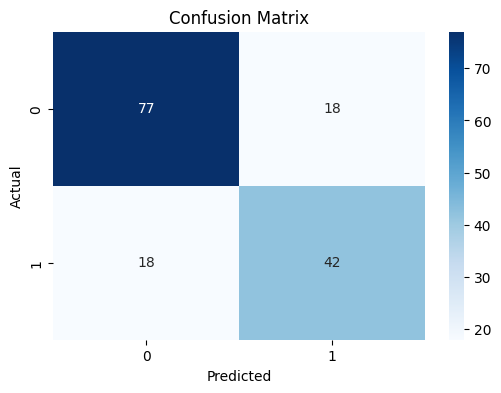

In [80]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

Confusion Matrix Meaning



Value	Meaning

TP	Correctly Predicted Survived

TN	Correctly Predicted Not Survived

FP	Wrongly Predicted Survived

FN	Wrongly Predicted Not Survived


In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#   Accuracy, Precision, Recall, F1 Score

### Precision

In [84]:
precision = precision_score(y_test, y_pred)
print('Precision:', precision)

Precision: 0.7


Out of the predicted survival figures, how many actually survived?

### Recall

In [85]:
recall = recall_score(y_test, y_pred)
print('Recall:', recall)

Recall: 0.7


Meaning

How many of the actual suspects were correctly predicted?

### F1 Score

In [86]:
f1 = f1_score(y_test, y_pred)
print('F1 Score:', f1)

F1 Score: 0.7


Meaning

Precision aur Recall ka balance.

## Full Classification Report

In [87]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        95
           1       0.70      0.70      0.70        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



# New Data Prediction



---
Now we will predict the new passenger.



In [89]:
new_data = pd.DataFrame({
    'Pclass': [3],
    'Sex': [1],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': [2]
})

###  Scalin new Data

In [90]:
new_data_scaled = scaler.transform(new_data)

## Final Predicyion

In [92]:
prediction = model.predict(new_data_scaled)

print(prediction)


if prediction[0] == 1:
    print('Passenger Survived')
else:
    print('Passenger Did Not Survive')

[0]
Passenger Did Not Survive
